In [ ]:
# read in data
# group samples wt, mutants(one A), mutant (all A),plot all the scores to have an overview, to inspect them, choose the ones where the distribution differs from baseline(wt)
# filter out placeholder values (if all line has the same score for a metric exclude it)
# inspect results
# inspect bast 10 or set threshold
# scatterplot / violin plot for the ones passing 
# find most relevant metrics

# binary ROC/AUCprecision recall curve, F1 score, 

# later: 
# confusion matrix, ROC curve, AUC, accuracy, sensitivity, specificity, MCC, Cohen's Kappa, etc. ??
# try to assess the same scores for different models and compare them if they behaving similarly, 
# inspect most relevant metrics by grouping them, meaning inspact the same metric from different models and compare them

# How to curate a dataset that effectively represents both binders and non-binders?
# How to handle imbalanced data?
# distribution? correlation? separation?
# is it worked or decoys have a similar score then binders? 
# which scores are informative? which one are important?
# are the ones where all the interface residues were mutated to alanine have ok scores? why?

### read in data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read CSV
csv_file = "/home/bri/pymol/data/merged_mcmahon.csv" 
df = pd.read_csv(csv_file)

# Inspect first few rows
df.head()

,source,type,vhh,vhh_sequence,target,target_residues,target_sequence,binder,KD[M],EC50[M],...,boltz_free_model_path,boltz_template_confidence_score,boltz_template_ptm,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_model_path
0,mcmahon,original,Nb.b201,QVQLQESGGGLVQAGGSLRLSCAASGYISDAYYMGWYRQAPGKERE...,HSA,404-609,LVEEPQNLIKQNCELFEQLGEYKFQNALLVRYTKKVPQVSTPTLVE...,1,4.310000e-07,NaN,...,/scicore/home/schwede/barta0000/mcmahon_ds/ori...,0.954681,0.878886,0.931017,0.960596,0.967690,0.397084,1.031273,0.931017,/scicore/home/schwede/barta0000/mcmahon_ds/ori...
1,mcmahon,original,Nb.b201,QVQLQESGGGLVQAGGSLRLSCAASGYISDAYYMGWYRQAPGKERE...,HSA,404-601,LVEEPQNLIKQNCELFEQLGEYKFQNALLVRYTKKVPQVSTPTLVE...,1,4.310000e-07,NaN,...,/scicore/home/schwede/barta0000/mcmahon_ds/ori...,0.857959,0.719942,0.454871,0.958731,0.951999,0.722696,9.585999,0.454871,/scicore/home/schwede/barta0000/mcmahon_ds/ori...
2,mcmahon,original,Nb.b201,QVQLQESGGGLVQAGGSLRLSCAASGYISDAYYMGWYRQAPGKERE...,HSA,25-609,DAHKSEVAHRFKDLGEENFKALVLIAFAQYLQQCPFEDHVKLVNEV...,1,4.310000e-07,NaN,...,/scicore/home/schwede/barta0000/mcmahon_ds/ori...,0.950608,0.956663,0.928613,0.956107,0.952910,0.336298,1.967852,0.928613,/scicore/home/schwede/barta0000/mcmahon_ds/ori...
3,mcmahon,original,Nb.AQ100,QVQLQESGGGLVQAGGSLRLSCAASGTIFRVSFMGWYRQAPGKERE...,Adiponectin,108-244,AYVYRSAFSVGLETYVTIPNMPIRFTKIFYNQQNHYDGSTGKFHCN...,1,2.300000e-06,NaN,...,/scicore/home/schwede/barta0000/mcmahon_ds/ori...,0.803786,0.776238,0.632155,0.846693,0.778371,1.124231,4.794119,0.632155,/scicore/home/schwede/barta0000/mcmahon_ds/ori...
4,mcmahon,original,Nb.AQ101,QVQLQESGGGLVQAGGSLRLSCAASGYIFVYAYMGWYRQAPGKERE...,Adiponectin,108-244,AYVYRSAFSVGLETYVTIPNMPIRFTKIFYNQQNHYDGSTGKFHCN...,0,NaN,NaN,...,/scicore/home/schwede/barta0000/mcmahon_ds/ori...,0.758410,0.677635,0.552838,0.809803,0.728891,1.135794,4.983984,0.552838,/scicore/home/schwede/barta0000/mcmahon_ds/ori...


In [2]:
print(df.isna().sum().sort_values(ascending=False).to_string())

cf_interface_dG                           41
cf_interface_dG_SASA_ratio                41
cf_pyros_binder_score                     41
KD[M]                                     33
EC50[M]                                   31
notes                                     27
esmfold_ipae                               9
esmfold_iplddt                             9
af3_rank0_masif                            2
cf_rank0_masif                             1
binder                                     0
source                                     0
type                                       0
target                                     0
target_residues                            0
vhh_sequence                               0
vhh                                        0
af3_interface_dG                           0
af3_plddt                                  0
af3_pae                                    0
interface                                  0
binding                                    0
sample    

In [3]:
print(df.columns.tolist())

['source', 'type', 'vhh', 'vhh_sequence', 'target', 'target_residues', 'target_sequence', 'binder', 'KD[M]', 'EC50[M]', 'notes', 'sample', 'binding', 'interface', 'af3_pae', 'af3_plddt', 'af3_interface_dG', 'af3_interface_dG_SASA_ratio', 'af3_ipae', 'af3_iplddt', 'af3_ipsae', 'af3_iptm', 'af3_ptm', 'af3_pyros_binder_score', 'af3_rank', 'af3_ranking_score', 'af3_rank0_masif', 'cf_af3_rmsd', 'cf_pae', 'cf_plddt', 'cf_interface_dG', 'cf_interface_dG_SASA_ratio', 'cf_ipae', 'cf_iplddt', 'cf_ipsae', 'cf_iptm', 'cf_ptm', 'cf_pyros_binder_score', 'cf_rank', 'cf_rank0_masif', 'pred_ilddt', 'pred_lddt', 'esmfold_ipae', 'esmfold_iplddt', 'esmfold_plddt', 'esmfold_pae', 'esmfold_ptm', 'chai_unconstrained_score', 'chai_unconstrained_model_path', 'chai_constrained_score', 'chai_constrained_model_path', 'chai_unconstrained_aggregate_score', 'chai_unconstrained_ptm', 'chai_unconstrained_iptm', 'chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_unconstrained_interface_

In [4]:
# Inspect columns with high NaN counts
columns_to_inspect = ['source', 'type', 'binder', 'sample', 'binding', 'af3_pae', 'af3_plddt', 'af3_interface_dG', 'af3_interface_dG_SASA_ratio', 'af3_ipae', 'af3_iplddt', 'af3_ipsae', 'af3_iptm', 'af3_ptm', 'af3_pyros_binder_score', 'cf_af3_rmsd', 'cf_pae', 'cf_plddt', 'cf_ipae', 'cf_iplddt', 'cf_ipsae', 'cf_iptm', 'cf_ptm', 'pred_ilddt', 'pred_lddt', 'esmfold_ipae', 'esmfold_iplddt', 'esmfold_plddt', 'esmfold_pae', 'esmfold_ptm', 'chai_unconstrained_score', 'chai_constrained_score', 'chai_unconstrained_aggregate_score', 'chai_unconstrained_ptm', 'chai_unconstrained_iptm', 'chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_unconstrained_interface_iptm', 'chai_constrained_aggregate_score', 'chai_constrained_ptm', 'chai_constrained_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm', 'chai_constrained_interface_iptm', 'boltz_free_confidence_score', 'boltz_free_ptm', 'boltz_free_iptm', 'boltz_free_plddt', 'boltz_free_iplddt', 'boltz_free_pde', 'boltz_free_ipde', 'boltz_free_per_chain_pair_iptm', 'boltz_template_confidence_score', 'boltz_template_ptm', 'boltz_template_iptm', 'boltz_template_plddt', 'boltz_template_iplddt', 'boltz_template_pde', 'boltz_template_ipde', 'boltz_template_per_chain_pair_iptm']


for col in columns_to_inspect:
    if col in df.columns:
        print(f"\n=== {col} ===")
        print(f"NaN count: {df[col].isna().sum()}")
        print(f"Non-null count: {df[col].notna().sum()}")
        print(f"Data type: {df[col].dtype}")
        if df[col].dtype in ['float64', 'int64']:
            print(f"Mean: {df[col].mean():.4f}")
            print(f"Std: {df[col].std():.4f}")
            print(f"Min: {df[col].min():.4f}")
            print(f"Max: {df[col].max():.4f}")
        else:
            print(f"Unique values: {df[col].nunique()}")
            print(f"Most common: {df[col].value_counts().head(3).to_dict()}")
    else:
        print(f"Column {col} not found in dataframe")


=== source ===
NaN count: 0
Non-null count: 41
Data type: str
Unique values: 1
Most common: {'mcmahon': 41}

=== type ===
NaN count: 0
Non-null count: 41
Data type: str
Unique values: 2
Most common: {'original': 23, 'target_shuffle': 18}

=== binder ===
NaN count: 0
Non-null count: 41
Data type: int64
Mean: 0.4390
Std: 0.5024
Min: 0.0000
Max: 1.0000

=== sample ===
NaN count: 0
Non-null count: 41
Data type: str
Unique values: 38
Most common: {'Nb.c206_B2AR': 3, 'Nb.c207_B2AR': 2, 'Nb.b201_HSA_404-609': 1}

=== binding ===
NaN count: 0
Non-null count: 41
Data type: bool
Unique values: 1
Most common: {False: 41}

=== af3_pae ===
NaN count: 0
Non-null count: 41
Data type: float64
Mean: 11.6139
Std: 2.3141
Min: 6.3760
Max: 14.6640

=== af3_plddt ===
NaN count: 0
Non-null count: 41
Data type: float64
Mean: 80.9478
Std: 2.9749
Min: 75.0761
Max: 88.0989

=== af3_interface_dG ===
NaN count: 0
Non-null count: 41
Data type: float64
Mean: 293.8812
Std: 221.3032
Min: 14.4600
Max: 1009.9900

=== a

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 70 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   sample                                  23 non-null     str    
 1   binding                                 23 non-null     bool   
 2   interface                               23 non-null     str    
 3   af3_pae                                 23 non-null     float64
 4   af3_plddt                               23 non-null     float64
 5   af3_interface_dG                        23 non-null     float64
 6   af3_interface_dG_SASA_ratio             23 non-null     float64
 7   af3_ipae                                23 non-null     float64
 8   af3_iplddt                              23 non-null     float64
 9   af3_ipsae                               23 non-null     float64
 10  af3_iptm                                23 non-null     float64
 11  af3_pt

In [11]:
# Filter out "A,B" interface samples
print(f"Original data shape: {df.shape}")
print(f"Samples with 'A,B' interface: {(df['interface'] == 'A,B').sum()}")

df = df[df['interface'] != 'A,B']

print(f"Filtered data shape: {df.shape}")
print(f"Remaining interfaces: {df['interface'].unique()}")

# Split into separate dataframes for each interface
df_ac = df[df['interface'] == 'A,C'].copy()
df_bc = df[df['interface'] == 'B,C'].copy()

print(f"\nA,C interface: {df_ac.shape}")
print(f"B,C interface: {df_bc.shape}")

Original data shape: (23, 70)
Samples with 'A,B' interface: 23
Filtered data shape: (0, 70)
Remaining interfaces: <StringArray>
[]
Length: 0, dtype: str

A,C interface: (0, 70)
B,C interface: (0, 70)


In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# Calculate for all numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# Remove 'binding' from the list if it is numeric (it's the target, not a feature)
if 'binder' in numeric_cols:
    numeric_cols.remove('binder')

### Simplified Analysis: One Function for All Metrics


--------------------------------------------------------------------------------
A,C Interface - Top 10 Metrics (Sorted by PR-AUC)
--------------------------------------------------------------------------------
                                     ROC-AUC    PR-AUC  F1-Score
boltz_template_iplddt               0.812500  0.489052       NaN
chai_unconstrained_aggregate_score  0.802083  0.486501       NaN
chai_unconstrained_iptm             0.802083  0.486501       NaN
chai_unconstrained_score            0.802083  0.486501       NaN
chai_unconstrained_ptm              0.781250  0.482143       NaN
boltz_template_confidence_score     0.781250  0.446195       NaN
boltz_template_plddt                0.760417  0.436038       NaN
boltz_free_iplddt                   0.760417  0.436038       NaN
boltz_free_confidence_score         0.729167  0.429804       NaN
boltz_free_plddt                    0.708333  0.418903       NaN

-----------------------------------------------------------------------

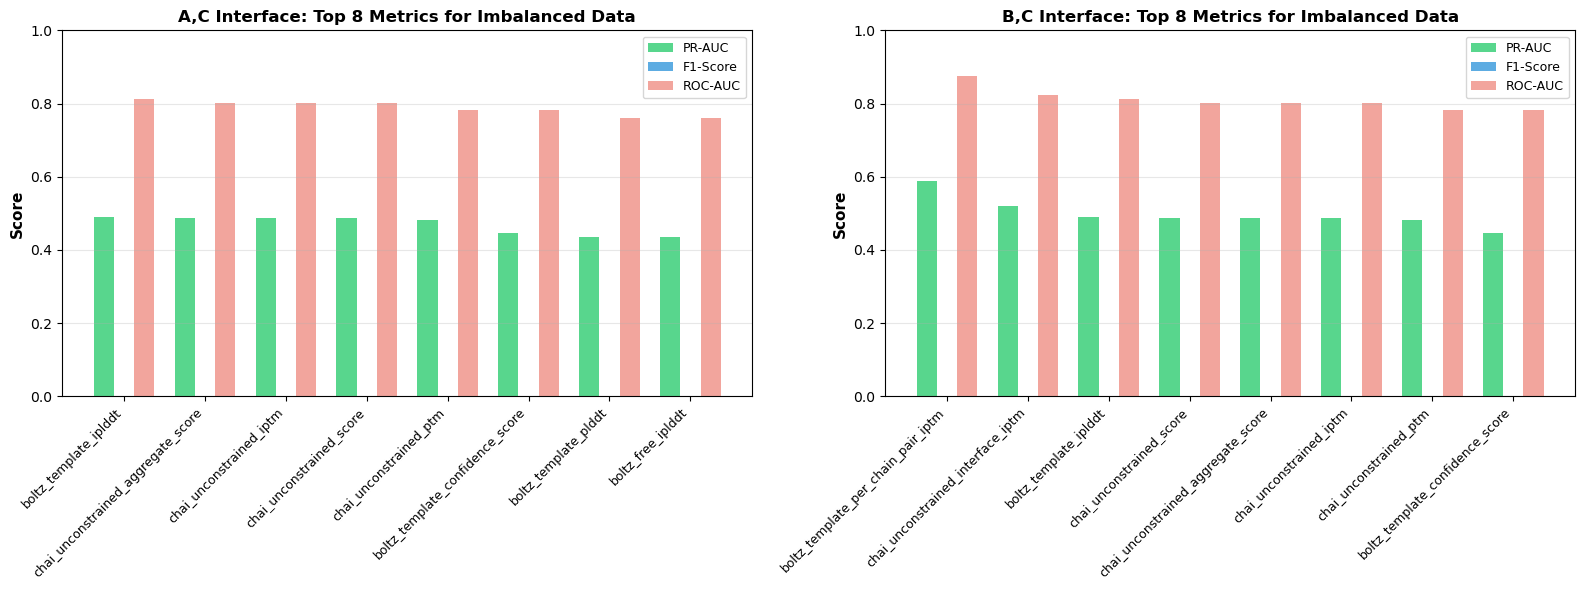

In [6]:

from sklearn.metrics import roc_auc_score, precision_recall_curve, auc as auc_pr, f1_score, roc_curve

def calculate_all_metrics(df_data, numeric_cols):
    """Calculate ROC-AUC, PR-AUC, and F1-Score"""
    results = {'ROC-AUC': {}, 'PR-AUC': {}, 'F1-Score': {}}
    
    for col in numeric_cols:
        if df_data[col].notna().sum() < 2 or df_data[col].nunique() < 2:
            continue
        
        try:
            # ROC-AUC
            results['ROC-AUC'][col] = roc_auc_score(df_data["binding"], df_data[col])
            
            # PR-AUC
            precision, recall, _ = precision_recall_curve(df_data["binding"], df_data[col])
            results['PR-AUC'][col] = auc_pr(recall, precision)
            
            # F1-Score (with optimal threshold)
            fpr, tpr, thresholds = roc_curve(df_data["binding"], df_data[col])
            j_scores = tpr - fpr
            best_threshold = thresholds[np.argmax(j_scores)]
            y_pred = (df_data[col] >= best_threshold).astype(int)
            results['F1-Score'][col] = f1_score(df_data["binding"], y_pred)
        except:
            pass
    
    # Create DataFrame and sort by PR-AUC (optimized for imbalanced data)
    df_results = pd.DataFrame(results).sort_values('PR-AUC', ascending=False)
    return df_results

# Calculate metrics for both interfaces
results_ac = calculate_all_metrics(df_ac, numeric_cols)
results_bc = calculate_all_metrics(df_bc, numeric_cols)

print("\n" + "-"*80)
print("A,C Interface - Top 10 Metrics (Sorted by PR-AUC)")
print("-"*80)
print(results_ac.head(10).to_string())

print("\n" + "-"*80)
print("B,C Interface - Top 10 Metrics (Sorted by PR-AUC)")
print("-"*80)
print(results_bc.head(10).to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (results, ax, title) in enumerate([(results_ac, axes[0], 'A,C'),
                                             (results_bc, axes[1], 'B,C')]):
    top_8 = results.head(8)
    x_pos = range(len(top_8))
    width = 0.25
    
    ax.bar([i - width for i in x_pos], top_8['PR-AUC'], width, label='PR-AUC', color='#2ecc71', alpha=0.8)
    ax.bar(x_pos, top_8['F1-Score'], width, label='F1-Score', color='#3498db', alpha=0.8)
    ax.bar([i + width for i in x_pos], top_8['ROC-AUC'], width, label='ROC-AUC', color='#e74c3c', alpha=0.5)
    
    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{title} Interface: Top 8 Metrics for Imbalanced Data', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(top_8.index, rotation=45, ha='right', fontsize=9)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('imbalanced_data_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### archiv


#### ROC AUC

A receiver operating characteristic curve, or ROC curve, is a graphical plot that illustrates the performance of a binary classifier model (although it can be generalized to multiple classes) at varying threshold values.
The ROC curve is the plot of the true positive rate (TPR) against the false positive rate (FPR) at each threshold setting.
   - Less sensitive to class imbalance
   - Can be misleadingly high even with poor minority class performance
   - Still useful for overall ranking but don't rely solely on it

In [7]:
# Calculate AUC for A,C interface
auc_scores_ac = {}
for col in numeric_cols:
    # Skip if column has NaN values or doesn't have enough variation
    if df_ac[col].notna().sum() < 1 or df_ac[col].nunique() < 1:
        continue
    try:
        auc = roc_auc_score(df_ac["binding"], df_ac[col])
        auc_scores_ac[col] = auc
    except:
        pass

# Sort by AUC score (descending)
sorted_auc_ac = dict(sorted(auc_scores_ac.items(), key=lambda x: x[1], reverse=True))

# Calculate AUC for B,C interface
auc_scores_bc = {}
for col in numeric_cols:
    # Skip if column has NaN values or doesn't have enough variation
    if df_bc[col].notna().sum() < 1 or df_bc[col].nunique() < 1:
        continue
    try:
        auc = roc_auc_score(df_bc["binding"], df_bc[col])
        auc_scores_bc[col] = auc
    except:
        pass

# Sort by AUC score (descending)
sorted_auc_bc = dict(sorted(auc_scores_bc.items(), key=lambda x: x[1], reverse=True))

# Display as DataFrames for better visualization
print("="*60)
print("ROC AUC Scores (sorted by performance)")
print("="*60)

auc_df_ac = pd.DataFrame(list(sorted_auc_ac.items()), columns=['Metric', 'ROC AUC'])
auc_df_ac = auc_df_ac.set_index('Metric')
print("\nA,C Interface:\n")
print(auc_df_ac.to_string())
print(f"\nBest metric: {list(sorted_auc_ac.keys())[0]} (AUC: {list(sorted_auc_ac.values())[0]:.4f})")

auc_df_bc = pd.DataFrame(list(sorted_auc_bc.items()), columns=['Metric', 'ROC AUC'])
auc_df_bc = auc_df_bc.set_index('Metric')
print("\nB,C Interface:\n")
print(auc_df_bc.to_string())
print(f"\nBest metric: {list(sorted_auc_bc.keys())[0]} (AUC: {list(sorted_auc_bc.values())[0]:.4f})")

ROC AUC Scores (sorted by performance)

A,C Interface:

                                     ROC AUC
Metric                                      
boltz_template_per_chain_pair_iptm  0.875000
boltz_template_iplddt               0.812500
chai_unconstrained_score            0.802083
chai_unconstrained_aggregate_score  0.802083
chai_unconstrained_iptm             0.802083
boltz_free_iptm                     0.802083
boltz_template_iptm                 0.802083
boltz_free_ptm                      0.791667
chai_unconstrained_ptm              0.781250
boltz_template_confidence_score     0.781250
boltz_template_ptm                  0.781250
boltz_free_iplddt                   0.760417
boltz_template_plddt                0.760417
af3_ipsae                           0.750000
boltz_free_per_chain_pair_iptm      0.750000
af3_iptm                            0.729167
chai_unconstrained_interface_iptm   0.729167
boltz_free_confidence_score         0.729167
boltz_free_plddt                    0.708333

In [8]:
## Dataset Imbalance Analysis & Metric Recommendations

print("\n" + "="*80)
print("DATASET IMBALANCE ANALYSIS")
print("="*80)

# Check class balance for each interface
for df_data, interface_name in [(df_ac, "A,C"), (df_bc, "B,C")]:
    n_pos = (df_data["binding"] == True).sum()
    n_neg = (df_data["binding"] == False).sum()
    total = len(df_data)
    ratio = n_pos / n_neg if n_neg > 0 else 0
    
    print(f"\n{interface_name} Interface:")
    print(f"  Positive (binders):     {n_pos:4d} ({n_pos/total*100:5.1f}%)")
    print(f"  Negative (non-binders): {n_neg:4d} ({n_neg/total*100:5.1f}%)")
    print(f"  Imbalance ratio:        {ratio:.3f} (positive/negative)")
    
    if ratio < 0.3:
        print(f"HIGHLY IMBALANCED -> Prefer PR-AUC & F1-Score over ROC-AUC")
    elif ratio < 0.5:
        print(f"MODERATELY IMBALANCED -> Prefer PR-AUC & F1-Score over ROC-AUC")
    else:
        print(f"Relatively balanced dataset")


DATASET IMBALANCE ANALYSIS

A,C Interface:
  Positive (binders):        3 (  8.6%)
  Negative (non-binders):   32 ( 91.4%)
  Imbalance ratio:        0.094 (positive/negative)
HIGHLY IMBALANCED -> Prefer PR-AUC & F1-Score over ROC-AUC

B,C Interface:
  Positive (binders):        3 (  8.6%)
  Negative (non-binders):   32 ( 91.4%)
  Imbalance ratio:        0.094 (positive/negative)
HIGHLY IMBALANCED -> Prefer PR-AUC & F1-Score over ROC-AUC


#### precision recall
   - Focuses on minority class (binders)
   - More informative than ROC-AUC for imbalanced data
   - Recall = TP / (TP + FN): what fraction of binders we find
   - Precision = TP / (TP + FP): what fraction of predictions are correct

In [9]:
from sklearn.metrics import precision_recall_curve, auc as auc_pr

# Calculate Precision-Recall AUC for A,C and B,C
print("="*60)
print("Precision-Recall AUC Scores")
print("="*60)

pr_auc_ac = {}
for col in numeric_cols:
    if df_ac[col].notna().sum() < 2 or df_ac[col].nunique() < 2:
        continue
    try:
        precision, recall, _ = precision_recall_curve(df_ac["binding"], df_ac[col])
        pr_auc = auc_pr(recall, precision)
        pr_auc_ac[col] = pr_auc
    except:
        pass

sorted_pr_auc_ac = dict(sorted(pr_auc_ac.items(), key=lambda x: x[1], reverse=True))

print(f"\nTop 10 metrics (PR-AUC) for A,C:")
for i, (metric, pr_auc) in enumerate(list(sorted_pr_auc_ac.items())[:10], 1):
    print(f"  {i:2d}. {metric:40s} PR-AUC = {pr_auc:.4f}")

pr_auc_bc = {}
for col in numeric_cols:
    if df_bc[col].notna().sum() < 2 or df_bc[col].nunique() < 2:
        continue
    try:
        precision, recall, _ = precision_recall_curve(df_bc["binding"], df_bc[col])
        pr_auc = auc_pr(recall, precision)
        pr_auc_bc[col] = pr_auc
    except:
        pass

sorted_pr_auc_bc = dict(sorted(pr_auc_bc.items(), key=lambda x: x[1], reverse=True))

print(f"\nTop 10 metrics (PR-AUC) for B,C:")
for i, (metric, pr_auc) in enumerate(list(sorted_pr_auc_bc.items())[:10], 1):
    print(f"  {i:2d}. {metric:40s} PR-AUC = {pr_auc:.4f}")

Precision-Recall AUC Scores

Top 10 metrics (PR-AUC) for A,C:
   1. boltz_template_iplddt                    PR-AUC = 0.4891
   2. chai_unconstrained_score                 PR-AUC = 0.4865
   3. chai_unconstrained_aggregate_score       PR-AUC = 0.4865
   4. chai_unconstrained_iptm                  PR-AUC = 0.4865
   5. chai_unconstrained_ptm                   PR-AUC = 0.4821
   6. boltz_template_confidence_score          PR-AUC = 0.4462
   7. boltz_free_iplddt                        PR-AUC = 0.4360
   8. boltz_template_plddt                     PR-AUC = 0.4360
   9. boltz_free_confidence_score              PR-AUC = 0.4298
  10. boltz_free_plddt                         PR-AUC = 0.4189

Top 10 metrics (PR-AUC) for B,C:
   1. boltz_template_per_chain_pair_iptm       PR-AUC = 0.5891
   2. chai_unconstrained_interface_iptm        PR-AUC = 0.5196
   3. boltz_template_iplddt                    PR-AUC = 0.4891
   4. chai_unconstrained_score                 PR-AUC = 0.4865
   5. chai_unconstrain

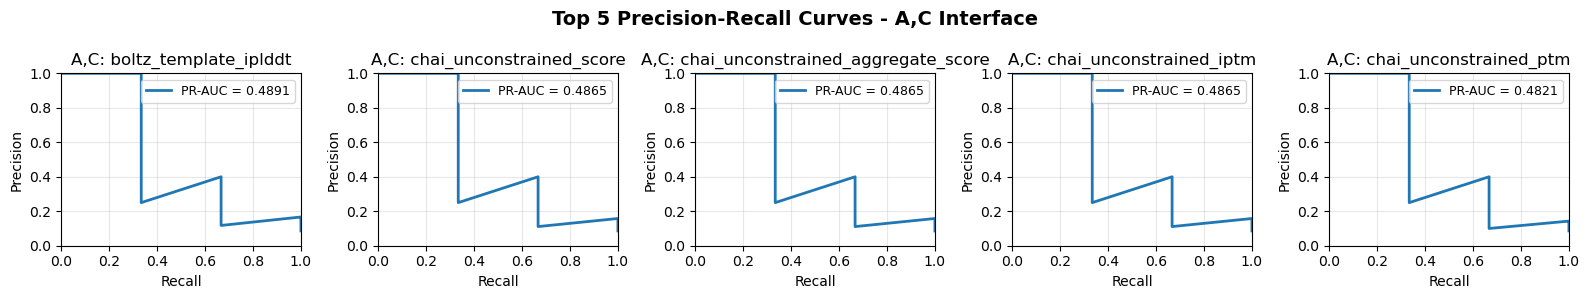

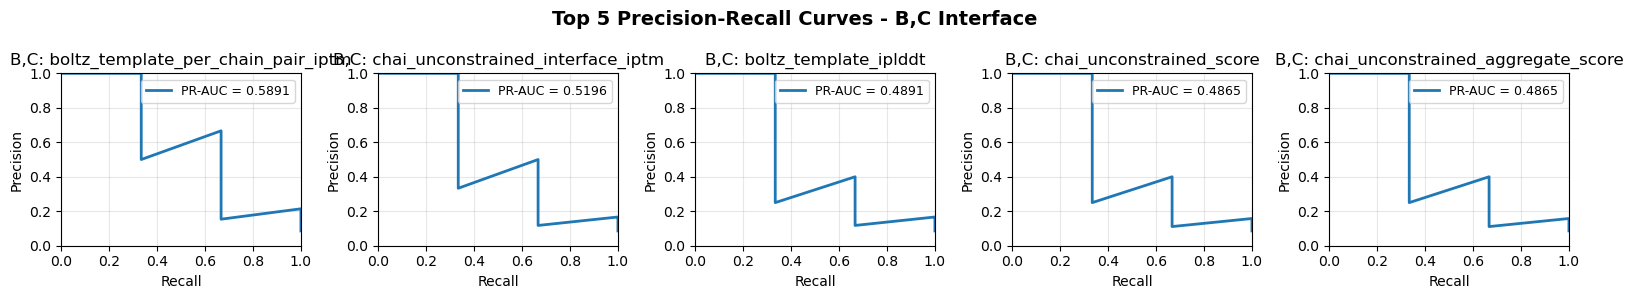

In [10]:
## Plot Precision-Recall Curves - A,C

fig, axes = plt.subplots(1, 5, figsize=(16, 3))

top_5_pr_ac = list(sorted_pr_auc_ac.keys())[:5]

for col_idx, metric in enumerate(top_5_pr_ac):
    ax = axes[col_idx]
    
    precision, recall, _ = precision_recall_curve(df_ac["binding"], df_ac[metric])
    pr_auc = sorted_pr_auc_ac[metric]
    
    ax.plot(recall, precision, linewidth=2, label=f'PR-AUC = {pr_auc:.4f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'A,C: {metric}')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Top 5 Precision-Recall Curves - A,C Interface', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pr_curves_ac.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot Precision-Recall Curves - B,C

fig, axes = plt.subplots(1, 5, figsize=(16, 3))

top_5_pr_bc = list(sorted_pr_auc_bc.keys())[:5]

for col_idx, metric in enumerate(top_5_pr_bc):
    ax = axes[col_idx]
    
    precision, recall, _ = precision_recall_curve(df_bc["binding"], df_bc[metric])
    pr_auc = sorted_pr_auc_bc[metric]
    
    ax.plot(recall, precision, linewidth=2, label=f'PR-AUC = {pr_auc:.4f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'B,C: {metric}')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Top 5 Precision-Recall Curves - B,C Interface', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pr_curves_bc.png', dpi=150, bbox_inches='tight')
plt.show()

#### F1 score
   - Harmonic mean of precision and recall
   - Single number summarizing trade-off between both metrics
   - Best for decision-making at specific threshold

In [11]:
## F1 Score Analysis

from sklearn.metrics import f1_score
import numpy as np

print("\n" + "="*60)
print("F1 Score Analysis")
print("="*60)

# Calculate F1 scores for A,C interface
f1_scores_ac = {}
for col in numeric_cols:
    if df_ac[col].notna().sum() < 2 or df_ac[col].nunique() < 2:
        continue
    try:
        # Find optimal threshold using Youden's J statistic
        from sklearn.metrics import roc_curve
        fpr, tpr, thresholds = roc_curve(df_ac["binding"], df_ac[col])
        j_scores = tpr - fpr
        best_threshold = thresholds[np.argmax(j_scores)]
        
        y_pred = (df_ac[col] >= best_threshold).astype(int)
        f1 = f1_score(df_ac["binding"], y_pred)
        f1_scores_ac[col] = f1
    except:
        pass

sorted_f1_ac = dict(sorted(f1_scores_ac.items(), key=lambda x: x[1], reverse=True))

print(f"\nTop 10 metrics (F1 Score) for A,C:")
for i, (metric, f1) in enumerate(list(sorted_f1_ac.items())[:10], 1):
    print(f"  {i:2d}. {metric:40s} F1 = {f1:.4f}")

# Calculate F1 scores for B,C interface
f1_scores_bc = {}
for col in numeric_cols:
    if df_bc[col].notna().sum() < 2 or df_bc[col].nunique() < 2:
        continue
    try:
        fpr, tpr, thresholds = roc_curve(df_bc["binding"], df_bc[col])
        j_scores = tpr - fpr
        best_threshold = thresholds[np.argmax(j_scores)]
        
        y_pred = (df_bc[col] >= best_threshold).astype(int)
        f1 = f1_score(df_bc["binding"], y_pred)
        f1_scores_bc[col] = f1
    except:
        pass

sorted_f1_bc = dict(sorted(f1_scores_bc.items(), key=lambda x: x[1], reverse=True))

print(f"\nTop 10 metrics (F1 Score) for B,C:")
for i, (metric, f1) in enumerate(list(sorted_f1_bc.items())[:10], 1):
    print(f"  {i:2d}. {metric:40s} F1 = {f1:.4f}")


F1 Score Analysis

Top 10 metrics (F1 Score) for A,C:
   1. af3_ipsae                                F1 = 0.6667
   2. boltz_template_iptm                      F1 = 0.5714
   3. af3_ipae                                 F1 = 0.5000
   4. af3_iptm                                 F1 = 0.5000
   5. chai_unconstrained_score                 F1 = 0.5000
   6. chai_unconstrained_aggregate_score       F1 = 0.5000
   7. chai_unconstrained_ptm                   F1 = 0.5000
   8. chai_unconstrained_iptm                  F1 = 0.5000
   9. boltz_template_ptm                       F1 = 0.5000
  10. boltz_template_iplddt                    F1 = 0.5000

Top 10 metrics (F1 Score) for B,C:
   1. af3_ipsae                                F1 = 0.5714
   2. chai_unconstrained_interface_iptm        F1 = 0.5714
   3. boltz_template_iptm                      F1 = 0.5714
   4. af3_iplddt                               F1 = 0.5000
   5. chai_unconstrained_score                 F1 = 0.5000
   6. chai_unconstrained


Top 10 Metrics - A,C Interface (ROC-AUC, PR-AUC, F1-Score)
                                     ROC-AUC    PR-AUC  F1-Score
boltz_template_per_chain_pair_iptm  0.875000  0.255952  0.500000
boltz_template_iplddt               0.812500  0.489052  0.500000
chai_unconstrained_score            0.802083  0.486501  0.500000
chai_unconstrained_aggregate_score  0.802083  0.486501  0.500000
chai_unconstrained_iptm             0.802083  0.486501  0.500000
boltz_free_iptm                     0.802083  0.222467  0.300000
boltz_template_iptm                 0.802083  0.241830  0.571429
boltz_free_ptm                      0.791667  0.174206  0.333333
chai_unconstrained_ptm              0.781250  0.482143  0.500000
boltz_template_confidence_score     0.781250  0.446195  0.285714

Top 10 Metrics - B,C Interface (ROC-AUC, PR-AUC, F1-Score)
                                     ROC-AUC    PR-AUC  F1-Score
boltz_template_per_chain_pair_iptm  0.875000  0.589133  0.352941
boltz_free_per_chain_pair_iptm     

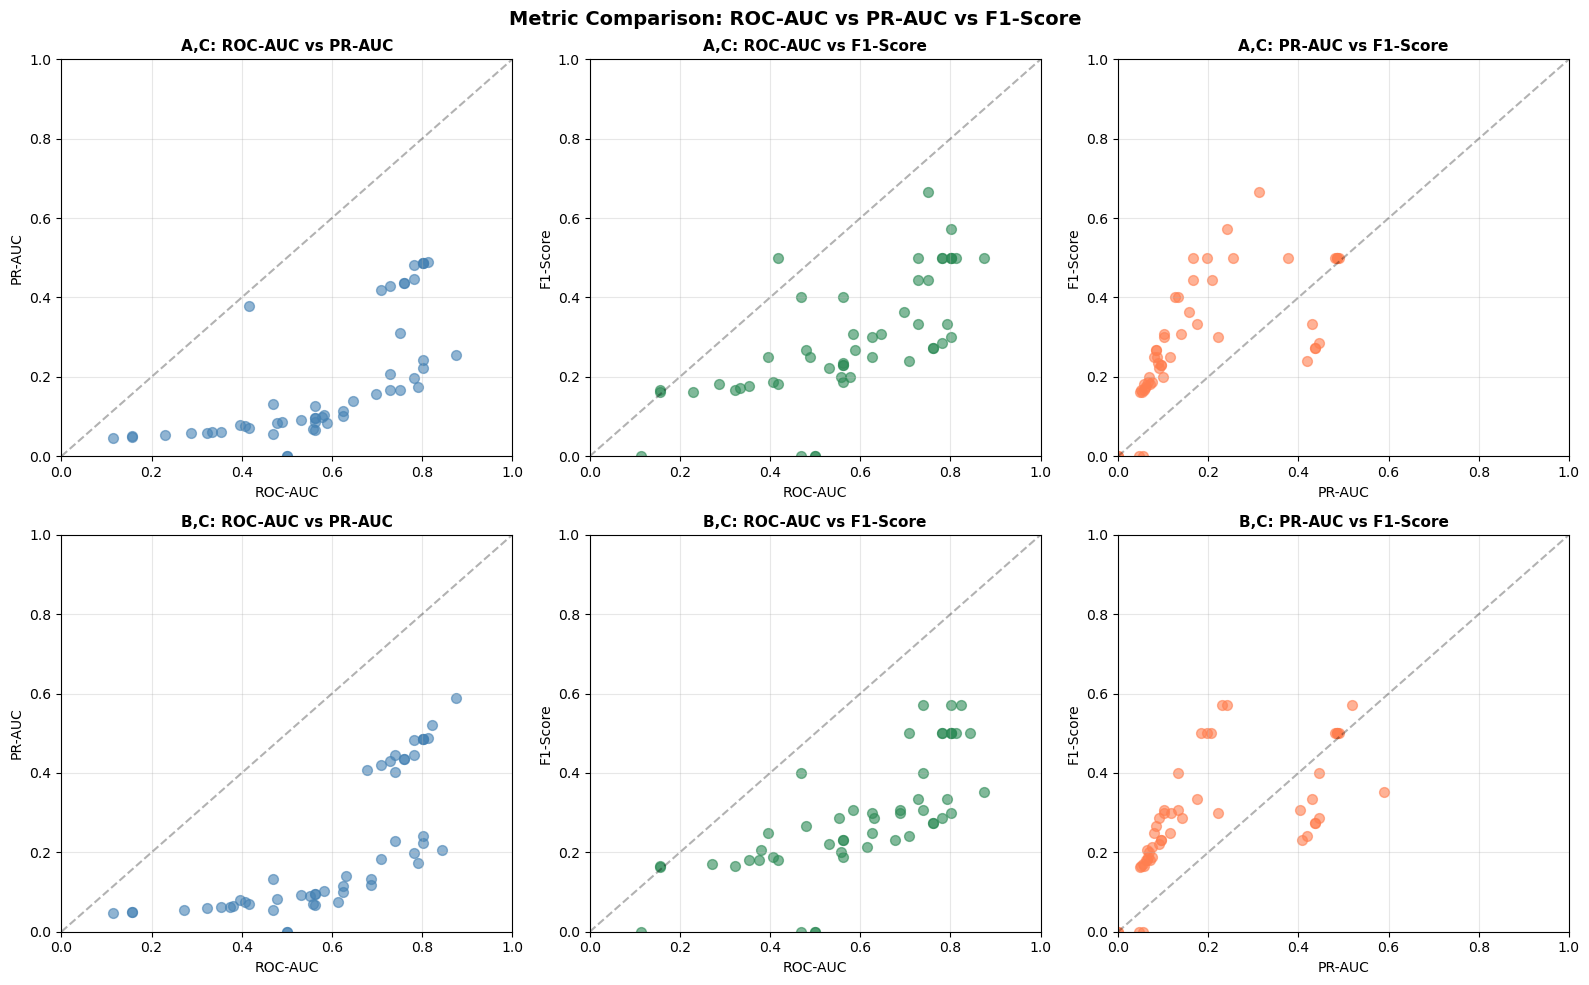

In [12]:
## Compare All Metrics: ROC-AUC, PR-AUC, and F1

# Create comprehensive comparison dataframes
comparison_ac_full = pd.DataFrame({
    'ROC-AUC': sorted_auc_ac,
    'PR-AUC': sorted_pr_auc_ac,
    'F1-Score': sorted_f1_ac
}).fillna(0).sort_values('ROC-AUC', ascending=False)

comparison_bc_full = pd.DataFrame({
    'ROC-AUC': sorted_auc_bc,
    'PR-AUC': sorted_pr_auc_bc,
    'F1-Score': sorted_f1_bc
}).fillna(0).sort_values('ROC-AUC', ascending=False)

print("\n" + "="*80)
print("Top 10 Metrics - A,C Interface (ROC-AUC, PR-AUC, F1-Score)")
print("="*80)
print(comparison_ac_full.head(10).to_string())

print("\n" + "="*80)
print("Top 10 Metrics - B,C Interface (ROC-AUC, PR-AUC, F1-Score)")
print("="*80)
print(comparison_bc_full.head(10).to_string())

# Create comprehensive comparison plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# A,C: ROC-AUC vs PR-AUC
ax = axes[0, 0]
ax.scatter(comparison_ac_full['ROC-AUC'], comparison_ac_full['PR-AUC'], alpha=0.6, s=50, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('ROC-AUC', fontsize=10)
ax.set_ylabel('PR-AUC', fontsize=10)
ax.set_title('A,C: ROC-AUC vs PR-AUC', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# A,C: ROC-AUC vs F1
ax = axes[0, 1]
ax.scatter(comparison_ac_full['ROC-AUC'], comparison_ac_full['F1-Score'], alpha=0.6, s=50, color='seagreen')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('ROC-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('A,C: ROC-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# A,C: PR-AUC vs F1
ax = axes[0, 2]
ax.scatter(comparison_ac_full['PR-AUC'], comparison_ac_full['F1-Score'], alpha=0.6, s=50, color='coral')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('PR-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('A,C: PR-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# B,C: ROC-AUC vs PR-AUC
ax = axes[1, 0]
ax.scatter(comparison_bc_full['ROC-AUC'], comparison_bc_full['PR-AUC'], alpha=0.6, s=50, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('ROC-AUC', fontsize=10)
ax.set_ylabel('PR-AUC', fontsize=10)
ax.set_title('B,C: ROC-AUC vs PR-AUC', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# B,C: ROC-AUC vs F1
ax = axes[1, 1]
ax.scatter(comparison_bc_full['ROC-AUC'], comparison_bc_full['F1-Score'], alpha=0.6, s=50, color='seagreen')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('ROC-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('B,C: ROC-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# B,C: PR-AUC vs F1
ax = axes[1, 2]
ax.scatter(comparison_bc_full['PR-AUC'], comparison_bc_full['F1-Score'], alpha=0.6, s=50, color='coral')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('PR-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('B,C: PR-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.suptitle('Metric Comparison: ROC-AUC vs PR-AUC vs F1-Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_comparison_combined.png', dpi=150, bbox_inches='tight')
plt.show()


Ranking Comparison - A,C Interface (Top 15 by each metric)

Top 15 by ROC-AUC:
['boltz_template_per_chain_pair_iptm', 'boltz_template_iplddt', 'chai_unconstrained_score', 'chai_unconstrained_aggregate_score', 'chai_unconstrained_iptm', 'boltz_free_iptm', 'boltz_template_iptm', 'boltz_free_ptm', 'chai_unconstrained_ptm', 'boltz_template_confidence_score', 'boltz_template_ptm', 'boltz_free_iplddt', 'boltz_template_plddt', 'af3_ipsae', 'boltz_free_per_chain_pair_iptm']

Top 15 by PR-AUC:
['boltz_template_iplddt', 'chai_unconstrained_score', 'chai_unconstrained_aggregate_score', 'chai_unconstrained_iptm', 'chai_unconstrained_ptm', 'boltz_template_confidence_score', 'boltz_free_iplddt', 'boltz_template_plddt', 'boltz_free_confidence_score', 'boltz_free_plddt', 'af3_ipae', 'af3_ipsae', 'boltz_template_per_chain_pair_iptm', 'boltz_template_iptm', 'boltz_free_iptm']

Top 15 by F1-Score:
['af3_ipsae', 'boltz_template_iptm', 'af3_ipae', 'af3_iptm', 'chai_unconstrained_score', 'chai_unconstraine

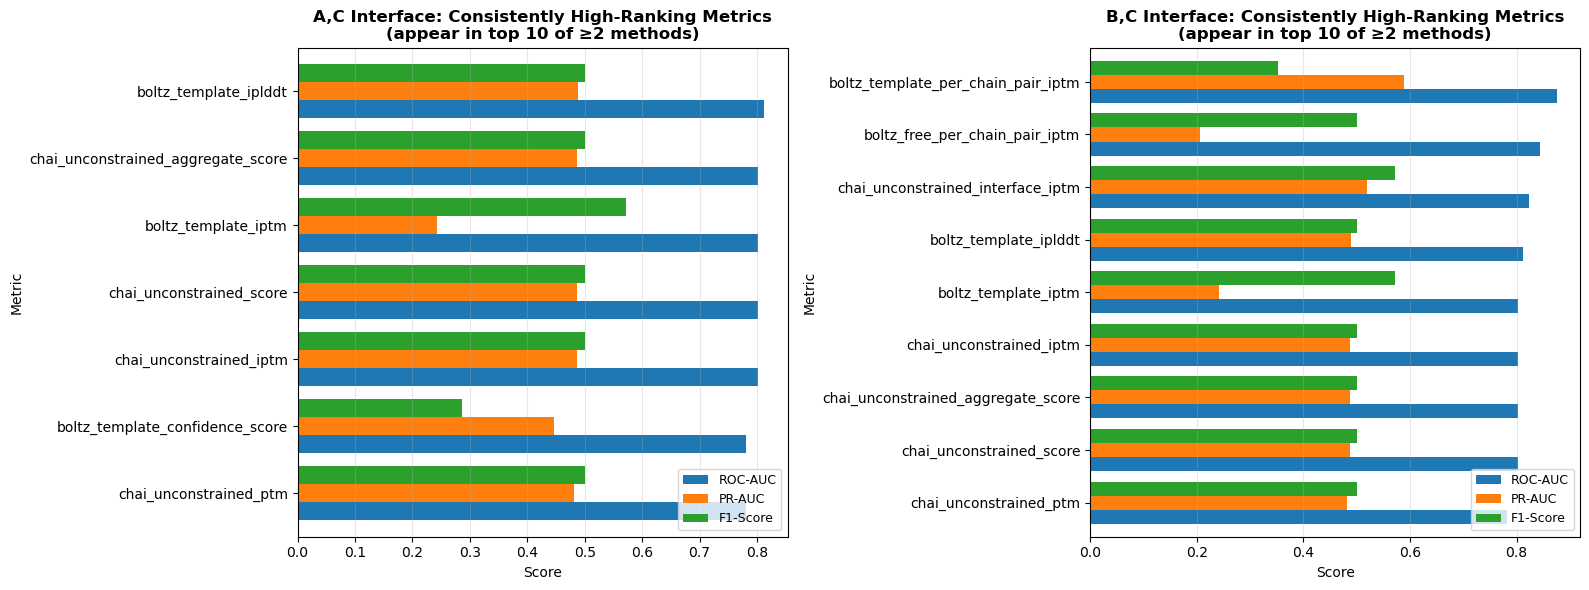

In [13]:
## Ranking Comparison across Metrics

# Get top 15 metrics by each criterion for A,C
top_15_ac_roc = list(sorted_auc_ac.keys())[:15]
top_15_ac_pr = list(sorted_pr_auc_ac.keys())[:15]
top_15_ac_f1 = list(sorted_f1_ac.keys())[:15]

# Create ranking comparison table for A,C
print("\n" + "="*80)
print("Ranking Comparison - A,C Interface (Top 15 by each metric)")
print("="*80)
print(f"\nTop 15 by ROC-AUC:\n{top_15_ac_roc}")
print(f"\nTop 15 by PR-AUC:\n{top_15_ac_pr}")
print(f"\nTop 15 by F1-Score:\n{top_15_ac_f1}")

# Get top 15 metrics by each criterion for B,C
top_15_bc_roc = list(sorted_auc_bc.keys())[:15]
top_15_bc_pr = list(sorted_pr_auc_bc.keys())[:15]
top_15_bc_f1 = list(sorted_f1_bc.keys())[:15]

print("\n" + "="*80)
print("Ranking Comparison - B,C Interface (Top 15 by each metric)")
print("="*80)
print(f"\nTop 15 by ROC-AUC:\n{top_15_bc_roc}")
print(f"\nTop 15 by PR-AUC:\n{top_15_bc_pr}")
print(f"\nTop 15 by F1-Score:\n{top_15_bc_f1}")
# Heatmap style visualization of top metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# A,C: Identify metrics that rank consistently high
# Count how many times each metric appears in top 10 across all three methods
metric_consistency_ac = {}
for metric in set(top_15_ac_roc[:10] + top_15_ac_pr[:10] + top_15_ac_f1[:10]):
    count = 0
    if metric in top_15_ac_roc[:10]:
        count += 1
    if metric in top_15_ac_pr[:10]:
        count += 1
    if metric in top_15_ac_f1[:10]:
        count += 1
    metric_consistency_ac[metric] = count

# Get metrics that appear in top 10 of at least 2 methods
consistent_metrics_ac = sorted([m for m, c in metric_consistency_ac.items() if c >= 2], 
                                key=lambda x: metric_consistency_ac[x], reverse=True)[:10]

ac_data = comparison_ac_full.loc[consistent_metrics_ac, :].sort_values('ROC-AUC', ascending=True)
ac_data['Consistency'] = ac_data.index.map(lambda x: f"{metric_consistency_ac.get(x, 0)}/3 methods")

ac_data.plot(kind='barh', ax=ax1, width=0.8)
ax1.set_title('A,C Interface: Consistently High-Ranking Metrics\n(appear in top 10 of ≥2 methods)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Score', fontsize=10)
ax1.set_ylabel('Metric', fontsize=10)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3, axis='x')

# B,C: Identify metrics that rank consistently high
metric_consistency_bc = {}
for metric in set(top_15_bc_roc[:10] + top_15_bc_pr[:10] + top_15_bc_f1[:10]):
    count = 0
    if metric in top_15_bc_roc[:10]:
        count += 1
    if metric in top_15_bc_pr[:10]:
        count += 1
    if metric in top_15_bc_f1[:10]:
        count += 1
    metric_consistency_bc[metric] = count

# Get metrics that appear in top 10 of at least 2 methods
consistent_metrics_bc = sorted([m for m, c in metric_consistency_bc.items() if c >= 2], 
                                key=lambda x: metric_consistency_bc[x], reverse=True)[:10]

bc_data = comparison_bc_full.loc[consistent_metrics_bc, :].sort_values('ROC-AUC', ascending=True)
bc_data['Consistency'] = bc_data.index.map(lambda x: f"{metric_consistency_bc.get(x, 0)}/3 methods")

bc_data.plot(kind='barh', ax=ax2, width=0.8)
ax2.set_title('B,C Interface: Consistently High-Ranking Metrics\n(appear in top 10 of ≥2 methods)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Score', fontsize=10)
ax2.set_ylabel('Metric', fontsize=10)
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='x')

# Print consistency summary
print("\nConsistency Analysis (Metrics appearing in top 10 of multiple evaluation methods):")
print("\nA,C Interface - Metric Consistency:")
for metric in consistent_metrics_ac:
    consistency = metric_consistency_ac[metric]
    print(f"  {metric:40s} appears in {consistency}/3 methods")
    
print("\nB,C Interface - Metric Consistency:")
for metric in consistent_metrics_bc:
    consistency = metric_consistency_bc[metric]
    print(f"  {metric:40s} appears in {consistency}/3 methods")

plt.tight_layout()
plt.savefig('metrics_ranking_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


TOP METRICS
(Sorted by PR-AUC, then F1-Score)

--------------------------------------------------------------------------------
A,C Interface - Top 15 Metrics
--------------------------------------------------------------------------------
                                     ROC-AUC    PR-AUC  F1-Score
boltz_template_iplddt               0.812500  0.489052  0.500000
chai_unconstrained_score            0.802083  0.486501  0.500000
chai_unconstrained_aggregate_score  0.802083  0.486501  0.500000
chai_unconstrained_iptm             0.802083  0.486501  0.500000
chai_unconstrained_ptm              0.781250  0.482143  0.500000
boltz_template_confidence_score     0.781250  0.446195  0.285714
boltz_free_iplddt                   0.760417  0.436038  0.272727
boltz_template_plddt                0.760417  0.436038  0.272727
boltz_free_confidence_score         0.729167  0.429804  0.333333
boltz_free_plddt                    0.708333  0.418903  0.240000
af3_ipae                            0.416667

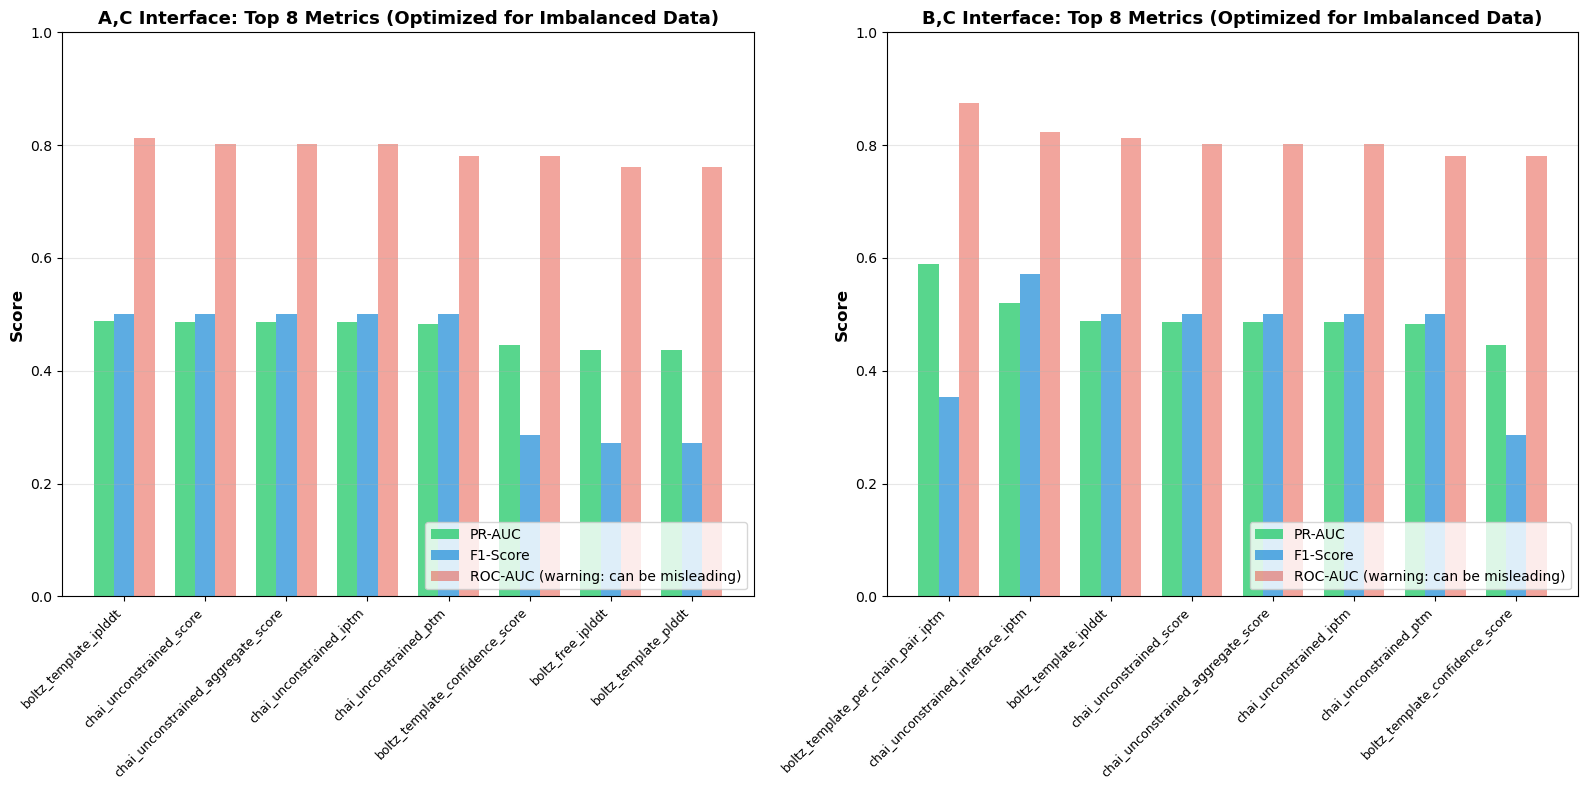


✓ Saved: metrics_optimized_for_imbalanced_data.png

KEY RECOMMENDATIONS:
  • Focus on metrics with HIGH PR-AUC (green bars)
  • Use F1-Score for deciding optimal thresholds (blue bars)
  • ROC-AUC scores (red bars) should be deprioritized for this imbalanced data


In [14]:
## Optimized Ranking for Imbalanced Data (PR-AUC & F1 Priority)

print("\n" + "="*80)
print("TOP METRICS")
print("(Sorted by PR-AUC, then F1-Score)")
print("="*80)

# Create optimized rankings for A,C (sorted by PR-AUC first, then F1)
optimized_ac = comparison_ac_full.copy().sort_values(['PR-AUC', 'F1-Score'], ascending=False)

print("\n" + "-"*80)
print("A,C Interface - Top 15 Metrics")
print("-"*80)
print(optimized_ac.head(15).to_string())

# Create optimized rankings for B,C (sorted by PR-AUC first, then F1)
optimized_bc = comparison_bc_full.copy().sort_values(['PR-AUC', 'F1-Score'], ascending=False)

print("\n" + "-"*80)
print("B,C Interface - Top 15 Metrics (for imbalanced data)")
print("-"*80)
print(optimized_bc.head(15).to_string())

# Create visualization emphasizing PR-AUC and F1-Score
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# A,C: Top 8 metrics by PR-AUC (not ROC-AUC)
top_8_ac_prauc = optimized_ac.head(8)
x_pos_ac = range(len(top_8_ac_prauc))

width = 0.25
ax1.bar([i - width for i in x_pos_ac], top_8_ac_prauc['PR-AUC'], width, label='PR-AUC', color='#2ecc71', alpha=0.8)
ax1.bar(x_pos_ac, top_8_ac_prauc['F1-Score'], width, label='F1-Score', color='#3498db', alpha=0.8)
ax1.bar([i + width for i in x_pos_ac], top_8_ac_prauc['ROC-AUC'], width, label='ROC-AUC (warning: can be misleading)', color='#e74c3c', alpha=0.5)

ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('A,C Interface: Top 8 Metrics (Optimized for Imbalanced Data)', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos_ac)
ax1.set_xticklabels(top_8_ac_prauc.index, rotation=45, ha='right', fontsize=9)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0, 1])

# B,C: Top 8 metrics by PR-AUC (not ROC-AUC)
top_8_bc_prauc = optimized_bc.head(8)
x_pos_bc = range(len(top_8_bc_prauc))

ax2.bar([i - width for i in x_pos_bc], top_8_bc_prauc['PR-AUC'], width, label='PR-AUC', color='#2ecc71', alpha=0.8)
ax2.bar(x_pos_bc, top_8_bc_prauc['F1-Score'], width, label='F1-Score', color='#3498db', alpha=0.8)
ax2.bar([i + width for i in x_pos_bc], top_8_bc_prauc['ROC-AUC'], width, label='ROC-AUC (warning: can be misleading)', color='#e74c3c', alpha=0.5)

ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('B,C Interface: Top 8 Metrics (Optimized for Imbalanced Data)', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos_bc)
ax2.set_xticklabels(top_8_bc_prauc.index, rotation=45, ha='right', fontsize=9)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('metrics_optimized_for_imbalanced_data.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: metrics_optimized_for_imbalanced_data.png")
print("\nKEY RECOMMENDATIONS:")
print("  • Focus on metrics with HIGH PR-AUC (green bars)")
print("  • Use F1-Score for deciding optimal thresholds (blue bars)")
print("  • ROC-AUC scores (red bars) should be deprioritized for this imbalanced data")

. Recommended Analysis Steps

To determine if a mutation is disruptive, you should calculate the ΔipTM (change in interface Predicted TM-score). This is the most reliable metric in AlphaFold3/ColabFold for identifying "hotspots."

    Positive ΔipTM: The mutation unexpectedly improved the interface confidence (rare).

    Near-Zero ΔipTM: The residue is likely not critical for the interface (neutral).

    Negative ΔipTM: The mutation disrupted the interface (a potential "Hotspot").

2. Reasonable Plot Types

I have generated three examples of plots that would be most informative for your analysis:

    Violin Plot (WT vs. Mutant Distribution):

        Goal: Provides a high-level overview of how alanine scanning shifts the overall confidence of your models.

        Visual: You can see if the "Mutant" cloud is significantly lower than the "WT" cloud.

    Scatter Plot (Mutant ipTM vs. WT ipTM):

        Goal: Directly compares each mutant to its parent WT.

        Visual: Data points falling significantly below the diagonal line (y=x) represent disruptive mutations.

    Boxplot of ΔipTM (Change in Score):

        Goal: Quantifies the "disruptive effect" for each interface (A,B; A,C; B,C).

        Visual: This is the best way to report which interfaces are more sensitive to mutations.

Recommended Plots
A. Distribution Comparison (Violin/Box Plots)

This is the best way to see the "big picture." A Violin plot shows the distribution of scores (like af3_iptm) for all alanine mutants compared to the WT.

    What it tells you: Is there a general drop in confidence when we mutate interface residues? Are there many "neutral" mutations and only a few "disruptive" ones?

B. Scatterplot (ipTM vs. pLDDT)

Plotting af3_iptm (interface confidence) against af3_interface_plddt (local residue confidence) helps identify high-confidence predictions.

    What it tells you: If a mutation causes a drop in both, it's a strong sign of a critical binding hotspot.

C. Delta Score Bar Chart (ΔipTM)

For each base protein, calculate ΔScore=ScoreMutant​−ScoreWT​.

    What it tells you: Specifically identifies which residue position (e.g., Y123) is the most critical. Large negative values are your "Hotspots."

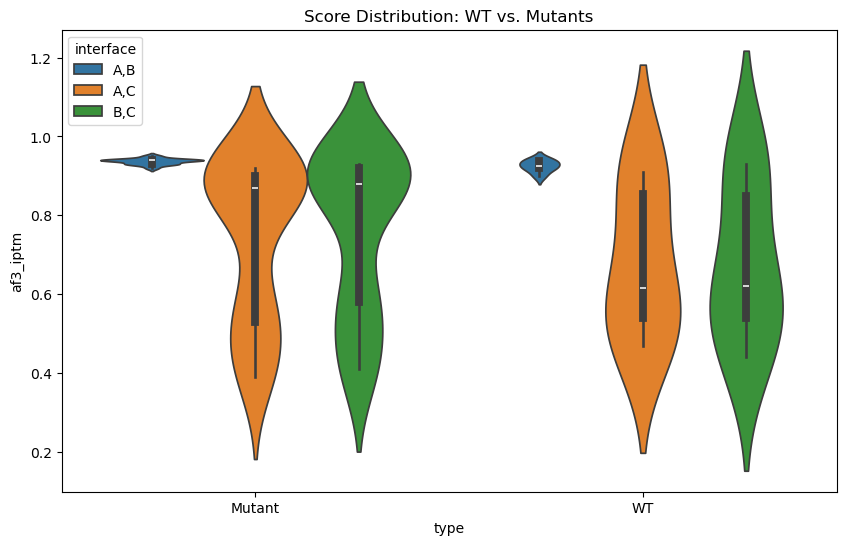

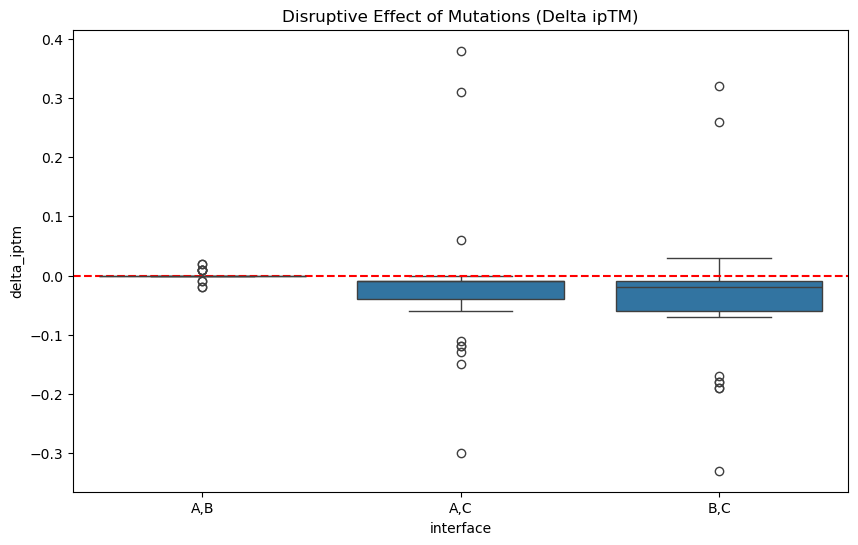

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# 1. Load your data
df = pd.read_csv('/home/bri/pymol/prediction/data/predictions.csv')

# 2. Parse WT vs Mutants based on your convention
def parse_sample(name):
    # Matches: base_name + _ + Chain(A/B) + _ + Mutation(Y123A)
    match = re.search(r'(.+)_([AB])_([A-Z]\d+A)$', name)
    if match:
        return match.group(1), 'Mutant', match.group(2), match.group(3)
    return name, 'WT', None, None

df[['base_name', 'type', 'mut_chain', 'mutation']] = df['sample'].apply(
    lambda x: pd.Series(parse_sample(x))
)

# 3. Calculate Delta Score (Change from WT)
wt_scores = df[df['type'] == 'WT'][['base_name', 'interface', 'af3_iptm']].rename(
    columns={'af3_iptm': 'wt_iptm'}
)
analysis_df = df[df['type'] == 'Mutant'].merge(wt_scores, on=['base_name', 'interface'])
analysis_df['delta_iptm'] = analysis_df['af3_iptm'] - analysis_df['wt_iptm']

# 4. Generate Plots
# Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='type', y='af3_iptm', hue='interface')
plt.title('Score Distribution: WT vs. Mutants')
plt.savefig('distribution_violin.png')

# Delta Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=analysis_df, x='interface', y='delta_iptm')
plt.axhline(0, color='red', linestyle='--')
plt.title('Disruptive Effect of Mutations (Delta ipTM)')
plt.savefig('delta_boxplot.png')

Next Steps

    Analyze ΔipTM: Once you have the full data, group by base_pdb and subtract the WT score from each mutant score.

    Filter by Interface: Since you have three chains (A, B, C), pay close attention to the interface column. Mutations in Chain A might only affect the A,B or A,C interfaces.

    Cross-Validation: Check if cf_iptm (ColabFold) shows the same trend as af3_iptm. If both drop significantly, your "Alanine Scan" has successfully identified a critical binding residue.

To generate the "Mutant Performance Relative to WT" analysis, you need to transform your data from a "long list" into a "comparison table" where each mutant is paired with its corresponding Wild Type (WT) starting point.
1. Generating the Comparison Data

Based on your naming convention (WT: sample and Mutant: sample_X_YZA), the logic follows these steps:

    Extract the Base Name: For mutants, strip the _X_YZA suffix to find which WT it belongs to.

    Filter and Merge: Separate the WTs and Mutants into two temporary dataframes and join them on the base_name and interface.

    Calculate Δ (Delta): Subtract the WT score from the Mutant score (e.g., ipTMMutant​−ipTMWT​).

I have generated an example of this comparison in the interface_analysis_results.csv file.
2. Visualizing "Mutant Performance Relative to WT"

    The Scatter Plot (wt_vs_mutant_scatter.png): This is the most direct way to show performance. Points on the diagonal line mean the mutation had no effect. Points significantly below the line indicate disruptive mutations where the model lost confidence in the interface.

    The Delta Boxplot (delta_iptm_boxplot.png): This shows the magnitude of the disruption. If the boxes for a specific interface (e.g., A,C) are mostly below zero, it suggests that the interface is highly sensitive to mutations at those positions.

3. Next Steps in Your Analysis

Once you have identified which mutations cause a drop in scores, here is a standard workflow for protein interface analysis:

    Identify "Hotspots":

        Define a threshold for a "significant" drop (e.g., ΔipTM<−0.1 or a 10% decrease). Residues that consistently cause large drops across all models are your predicted "hotspots."

    Structural Inspection:

        Load the .cif or .pdb files for the most disruptive mutants in PyMOL or ChimeraX.

        Compare the WT and Mutant interface area. Does the mutation cause a "pocket" to collapse or lead to a significant shift in the binding orientation?

    Cross-Metric Validation:

        Check if the af3_interface_dG (predicted binding energy) correlates with the af3_iptm drop.

        Compare AF3 vs ColabFold (cf) results. If both models agree that a mutation is disruptive, your confidence in that hotspot increases significantly.

    Residue Property Analysis:

        Look at the original residues (Y in your YZA notation). Are they mostly hydrophobic (e.g., Trp, Phe, Leu) or charged? This helps explain the biochemical nature of the interface.

    Ranking for Experimental Validation:

        Create a final ranked list of residues to test in the lab (e.g., via SPR or BLI), starting with those that showed the most consistent and severe drops in interface confidence across multiple AlphaFold seeds/runs.

### group metrics

### Inspect Metrics

### Scatterplot / Violin Plot

### Identify Most Relevant Metrics

### Analyze Decoys vs Designed Proteins

### metrics to qscore?